# PrizePicks Final Model

### Import Packages

In [1]:
import numpy as np
import pandas as pd
import re
from scipy.stats import binom
import requests
import lxml.html as lx
import time
import datetime
from datetime import date
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from selenium import webdriver
from selenium.webdriver.common.by import By

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

C:\Users\Zachary Chan\New folder\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Define Functions

In [2]:
def get_player_data(url, year):
    
    endpoint = url + year
    result = requests.get(endpoint)
    html = lx.fromstring(result.text)

    # scrape dates of games from 2025
    date_data = html.xpath('//td[@data-stat="date_game"]/a')
    for i in date_data:
        dates_list.append(i.text)

    # scrape opponents of games from 2025
    opp_data = html.xpath('//td[@data-stat="opp_id"]/a')
    for i in opp_data:
        opp_list.append(i.text)

    # scrape home or away data from 2025
    location_data = html.xpath('//td[@data-stat="game_location"]')
    for i in location_data:
        if i.text == '@':
            location_list.append('Away')
        if i.text == None:
            location_list.append('Home')

    # scrape points of games from 2025
    point_data = html.xpath('//td[@data-stat="pts"]')
    for i in point_data:
        point_list.append(i.text)
        
    # scrape assists of games from 2025
    assist_data = html.xpath('//td[@data-stat="ast"]')
    for i in assist_data:
        assist_list.append(i.text)
        
    # scrape rebounds of games from 2025
    rebound_data = html.xpath('//td[@data-stat="trb"]')
    for i in rebound_data:
        rebound_list.append(i.text)
        
    # scrape minutes played of games from 2025
    minutes_data = html.xpath('//td[@data-stat="mp"]')
    for i in minutes_data:
        minutes_list.append(i.text)
        
    # scrape fga of games from 2025
    fga_data = html.xpath('//td[@data-stat="fga"]')
    for i in fga_data:
        fga_list.append(i.text)
        
    # scrape fg_pct of games from 2025
    fg_pct_data = html.xpath('//td[@data-stat="fg_pct"]')
    for i in fg_pct_data:
        fg_pct_list.append(i.text)
        
        
def retrieve_rows_per_game(html): 
    per_game_table = html.xpath('//table[@id="per_game-team"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells


def retrieve_rows_advanced_team(html): 
    per_game_table = html.xpath('//table[@id="advanced-team"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells


def retrieve_rows_standings(html): 
    per_game_table = html.xpath('//table[@id="wnba_standings"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells


def retrieve_rows_schedule(html): 
    per_game_table = html.xpath('//table[@id="schedule"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells


def get_opp_team_data(year):
    opp_team_data_list = []
    
    endpoint = 'https://www.basketball-reference.com/wnba/years/' + year + '.html'
    result = requests.get(endpoint)
    html = lx.fromstring(result.text)
    
    per_game_df = pd.DataFrame(retrieve_rows_per_game(html))
    advanced_team_df = pd.DataFrame(retrieve_rows_advanced_team(html))
    advanced_team_df = advanced_team_df[1:]
    standings_df = pd.DataFrame(retrieve_rows_standings(html))
    
    opp_team_data_list.append(per_game_df)
    opp_team_data_list.append(advanced_team_df)
    opp_team_data_list.append(standings_df)
    
    return opp_team_data_list
    
    
def clean_team_data(opp_team_data_list):
    
    # rename the dataframes for clarity
    per_game_df = opp_team_data_list[0]
    advanced_team_df = opp_team_data_list[1]
    standings_df = opp_team_data_list[2]
    
    # fix headers
    per_game_df = per_game_df.rename(columns=per_game_df.iloc[0]).loc[1:]
    advanced_team_df = advanced_team_df.rename(columns=advanced_team_df.iloc[0]).loc[1:]
    standings_df = standings_df.rename(columns=standings_df.iloc[0]).loc[1:]
    
    # remove unnessecary columns
    per_game_df.drop('Rk', axis=1, inplace=True)
    advanced_team_df.drop(['Rk', 'Arena'], axis=1, inplace=True)
    
    # merge df's
    merged_df = pd.merge(per_game_df, advanced_team_df, on='Team', how='outer')
    merged_df = pd.merge(merged_df, standings_df, on='Team', how='outer')
    
    # remove empty columns
    merged_df.drop('\xa0', axis=1, inplace=True)

    opp_team_df = merged_df
    
    return opp_team_df


def get_data(url, years):
    
    # scrape player data for all years
    for year in years:
        get_player_data(url, year)
        time.sleep(random.uniform(1, 4))
        
    # store player data in dictionary
    data_dict = {
    'Date': dates_list,
    'Opp': opp_list,
    'Location': location_list,
    'PTS': point_list,
    'AST': assist_list,
    'REB': rebound_list,
    'Min': minutes_list,
    'FGA': fga_list,
    'FG_pct': fg_pct_list
    }
    # store player data in dataframe
    player_df = pd.DataFrame(data_dict)
    
    # scrape and clean opponent team data for all years
    final_opp_team_df = pd.DataFrame()
    for year in years:
        opp_team_data_list = get_opp_team_data(year) # scrapes data
        opp_team_df = clean_team_data(opp_team_data_list) # cleans data and combine into single dataframe 'opp_team_df'
        opp_team_df['Year'] = year # record year in new column
        final_opp_team_df = pd.concat([final_opp_team_df, opp_team_df])
        time.sleep(random.uniform(1, 4))
        
    # Some columns have the duplicate names, we will rename columns for clarity
    final_opp_team_df.columns.values[39] = 'O-eFG%'
    final_opp_team_df.columns.values[40] = 'O-TOV%'
    final_opp_team_df.columns.values[41] = 'O-ORB%'
    final_opp_team_df.columns.values[42] = 'O-FT/FGA'

    final_opp_team_df.columns.values[43] = 'D-eFG%'
    final_opp_team_df.columns.values[44] = 'D-TOV%'
    final_opp_team_df.columns.values[45] = 'D-ORB%'
    final_opp_team_df.columns.values[46] = 'D-FT/FG'
    
    return player_df, final_opp_team_df


def combine_data(player_df, opp_team_df):
    cols_to_convert = opp_team_df.columns[1:-1]

    for col in cols_to_convert:
        opp_team_df[col] = pd.to_numeric(opp_team_df[col], errors='coerce')
        opp_team_df[col] = opp_team_df[col].fillna(0).astype('float')
        
    # drop wins and losses bc w/l% encompasses the statistics already
    opp_team_df.drop(columns=['W_x', 'L_x', 'W_y', 'L_y'], inplace=True)
    
    # drop 'FG', '3P', '2P', 'FT' bc they are implied by attempts/percentange
    opp_team_df.drop(columns=['FG', '3P', '2P', 'FT'], inplace=True)
    
    # drop 'TRB' bc it is implied by 'ORB' + 'DRB'
    opp_team_df.drop(columns='TRB', inplace=True)
    
    # drop 'FTr', '3PAr' bc it is implied by FTA/FGA and 3PA/FGA
    opp_team_df.drop(columns=['FTr', '3PAr'], inplace=True)
    
    # drop 'PW', 'PL', 'SOS' (unnecessary)
    opp_team_df.drop(columns=['G', 'MP', 'PW', 'PL', 'SOS'], inplace=True)
    
    # remove MOV due to its correlation with SRS
    opp_team_df.drop(columns='MOV', inplace=True)
    
    # remove SRS due to its correlation with NRtg
    opp_team_df.drop(columns='SRS', inplace=True)
    
    # remove TS% due to its correlation with other variables
    opp_team_df.drop(columns='TS%', inplace=True)
    
    # remove ORtg due to their correlation with other variables
    opp_team_df.drop(columns='ORtg', inplace=True)
    
    # remove O-eFG% due to its correlation with FG%
    opp_team_df.drop(columns='O-eFG%', inplace=True)
    
    # remove O-FT/FGA due bc it is already implied
    opp_team_df.drop(columns='O-FT/FGA', inplace=True)
    
    # remove O-ORB% due bc it is already implied
    opp_team_df.drop(columns='O-ORB%', inplace=True)
    
    # remove O-TOV% due bc it is already implied
    opp_team_df.drop(columns='O-TOV%', inplace=True)
    
    # remove D-ORB% due bc it is already implied
    opp_team_df.drop(columns='D-ORB%', inplace=True)
    
    # remove D-FT/FG due bc it is already implied
    opp_team_df.drop(columns='D-FT/FG', inplace=True)
    
    # remove STL due bc it is already implied
    opp_team_df.drop(columns='STL', inplace=True)
    
    # remove GB due bc it is already implied
    opp_team_df.drop(columns='GB', inplace=True)
    
    # remove W/L% due bc it is already implied
    opp_team_df.drop(columns='W/L%', inplace=True)
    
    dates = player_df.iloc[:, 0]
    Month = []
    for date in dates:
        m = date[5:7]
        Month.append(m)
    player_df['Month'] = Month
    
    dates = player_df.iloc[:, 0]
    Year = []
    for date in dates:
        y = date[:4]
        Year.append(y)

    player_df['Year'] = Year
    
    dtype_mapping = {
        'Date': str,
        'Opp': str, 
        'Location': str, 
        'Month': str,
        'Year': str,
        'PTS': int,
        'AST': int,
        'REB': int,
        'FGA': int,
    }

    player_df = player_df.astype(dtype_mapping)
    
    # change 'Team' column to abbreviations to match the other dataframe
    abbrev = {
        'New York Liberty': 'NYL',
        'Phoenix Mercury': 'PHO',
        'Minnesota Lynx': 'MIN',
        'Atlanta Dream': 'ATL',
        'Indiana Fever': 'IND',
        'Seattle Storm': 'SEA',
        'Los Angeles Sparks': 'LAS',
        'Dallas Wings': 'DAL',
        'Las Vegas Aces': 'LVA',
        'Golden State Valkyries': 'GSV',
        'Chicago Sky': 'CHI',
        'Washington Mystics': 'WAS',
        'Connecticut Sun': 'CON',
        'New York Liberty*': 'NYL',
        'Phoenix Mercury*': 'PHO',
        'Minnesota Lynx*': 'MIN',
        'Atlanta Dream*': 'ATL',
        'Indiana Fever*': 'IND',
        'Seattle Storm*': 'SEA',
        'Los Angeles Sparks*': 'LAS',
        'Dallas Wings*': 'DAL',
        'Las Vegas Aces*': 'LVA',
        'Golden State Valkyries*': 'GSV',
        'Chicago Sky*': 'CHI',
        'Washington Mystics*': 'WAS',
        'Connecticut Sun*': 'CON',
        }

    # Replace city names with abbreviations
    opp_team_df['Team'] = opp_team_df['Team'].map(abbrev)
    
    # Rename to match other dataframe
    opp_team_df = opp_team_df.rename(columns={'Team': 'Opp'})
    
    # merge dataframes
    df = pd.merge(player_df, opp_team_df, on=['Opp', 'Year'], how='outer')
    
    # rename columns for clarity
    df = df.rename(columns={'Opp': 'Opponent',
                            'PTS_x': 'Player_PTS',
                            'AST_x': 'Player_AST',
                            'REB': 'Player_REB',
                            'MIN': 'Player_Min',
                            'FGA_x': 'Player_FGA',
                            'FG_pct': 'Player_FG%',
                            'FGA_y': 'Opp_FGA',
                            'FG%': 'Opp_FG%',
                            '3PA': 'Opp_3PA',
                            '3P%': 'Opp_3P%',
                            '2PA': 'Opp_2PA',
                            '2P%': 'Opp_2P%',
                            'FTA': 'Opp_FTA',
                            'FT%': 'Opp_FT%',
                            'ORB': 'Opp_ORB',
                            'DRB': 'Opp_DRB',
                            'AST_y': 'Opp_AST',
                            'BLK': 'Opp_BLK',
                            'TOV': 'Opp_TOV',
                            'PF': 'Opp_PF',
                            'PTS_y': 'Opp_PTS',
                            'Age': 'Opp_Age',
                            'NRtg': 'Opp_NRtg',
                            'DRtg': 'Opp_DRtg',
                            'Pace': 'Opp_Pace',
                            'D-eFG%': 'Opp_D-eFG%',
                            'D-TOV%': 'Opp_D-TOV%'})
    
    # remove empty rows
    df.dropna(subset=["Location"], inplace=True)
    
    return df


def engineer_features(df):
    
    # convert 'Date' column to datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # sort by date
    df = df.sort_values('Date').reset_index(drop=True)

    # compute difference in days between consecutive games
    df['DaysSinceLastGame'] = df['Date'].diff().dt.days

    # Mark back-to-back games (1 day apart)
    df['BackToBack'] = df['DaysSinceLastGame'] == 1

    # Convert to int (1 for True, 0 for False)
    df['BackToBack'] = df['BackToBack'].astype(int)
    
    # Create the categorical column
    def categorize_days(x):
        if pd.isna(x):
            return '0'       # First game (no prior)
        elif x >= 5:
            return '5+'
        else:
            return str(int(x))  # '1' to '4'

    df['DaysSinceLastGame'] = df['Date'].diff().dt.days
    df['DaysSinceLastGame_Cat'] = df['DaysSinceLastGame'].apply(categorize_days)
    
    def convert_min_to_float(min_str):
        try:
            if pd.isna(min_str):
                return np.nan
            minutes, seconds = map(int, min_str.split(':'))
            return minutes + seconds / 60
        except:
            return np.nan

    df['Min_float'] = df['Min'].apply(convert_min_to_float)


    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll5',
        'Player_AST': 'AST_Roll5',
        'Player_REB': 'REB_Roll5',
        'Min_float': 'Min_Roll5',
        'Player_FGA': 'FGA_Roll5',
        'Player_FG%': 'FGP_Roll5'
    }

    # Apply 5-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=5, min_periods=1).mean()
        
    df['PTS_ExpAvg'] = df['Player_PTS'].expanding().mean().shift(1)
    df['AST_ExpAvg'] = df['Player_AST'].expanding().mean().shift(1)
    df['REB_ExpAvg'] = df['Player_REB'].expanding().mean().shift(1)
    df['Min_ExpAvg'] = df['Min_float'].expanding().mean().shift(1)
    df['FGA_ExpAvg'] = df['Player_FGA'].expanding().mean().shift(1)
    df['FG%_ExpAvg'] = df['Player_FG%'].expanding().mean().shift(1)
    
    # create rolling points per minute
    rolling_points = df['PTS_Roll5']
    rolling_minutes = df['Min_Roll5']
    PointsPerMinute_Roll5 = [a / b for a, b in zip(rolling_points, rolling_minutes)]
    df['PointsPerMinute_Roll5'] = PointsPerMinute_Roll5
    
    # create rolling rebounds per minute
    rolling_rebounds = df['REB_Roll5']
    rolling_minutes = df['Min_Roll5']
    ReboundsPerMinute_Roll5 = [a / b for a, b in zip(rolling_rebounds, rolling_minutes)]
    df['ReboundsPerMinute_Roll5'] = ReboundsPerMinute_Roll5
    
    # create rolling assists per minute
    rolling_assists = df['AST_Roll5']
    rolling_minutes = df['Min_Roll5']
    AssistsPerMinute_Roll5 = [a / b for a, b in zip(rolling_assists, rolling_minutes)]
    df['AssistsPerMinute_Roll5'] = AssistsPerMinute_Roll5    
    
    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll3',
        'Player_AST': 'AST_Roll3',
        'Player_REB': 'REB_Roll3',
        'Min_float': 'Min_Roll3',
        'Player_FGA': 'FGA_Roll3',
        'Player_FG%': 'FGP_Roll3'
    }

    # Apply 3-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=3, min_periods=1).mean()
        
    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll10',
        'Player_AST': 'AST_Roll10',
        'Player_REB': 'REB_Roll10',
        'Min_float': 'Min_Roll10',
        'Player_FGA': 'FGA_Roll10',
        'Player_FG%': 'FGP_Roll10'
    }

    # Apply 3-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=10, min_periods=1).mean()
        
    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll15',
        'Player_AST': 'AST_Roll15',
        'Player_REB': 'REB_Roll15',
        'Min_float': 'Min_Roll15',
        'Player_FGA': 'FGA_Roll15',
        'Player_FG%': 'FGP_Roll15'
    }

    # Apply 5-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=15, min_periods=1).mean()
        
    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll20',
        'Player_AST': 'AST_Roll20',
        'Player_REB': 'REB_Roll20',
        'Min_float': 'Min_Roll20',
        'Player_FGA': 'FGA_Roll20',
        'Player_FG%': 'FGP_Roll20'
    }

    # Apply 5-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=20, min_periods=1).mean()
        
    df['Minutes_x_FGA'] = df['Min_Roll5'] * df['FGA_Roll5']
    df['Hot_Streak_PTS'] = (df['PTS_Roll5'] > df['PTS_Roll10']).astype(int)
    df['Hot_Streak_REB'] = (df['REB_Roll5'] > df['REB_Roll10']).astype(int)
    df['Hot_Streak_AST'] = (df['AST_Roll5'] > df['AST_Roll10']).astype(int)
    df['PTS_LastGame'] = df['Player_PTS'].shift(1)
    df['Min_LastGame'] = df['Min_float'].shift(1)
        
    return df


def train_xgb_model(df, target_column, categorical_features, numeric_features):

    # Drop rows with missing values
    all_features = categorical_features + numeric_features + [target_column]
    df_clean = df[all_features].dropna()

    X = df_clean[categorical_features + numeric_features]
    y = df_clean[target_column]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first'), categorical_features)
        ],
        remainder='passthrough'
    )

    # Fit preprocessor separately to get feature names
    preprocessor.fit(X_train)
    X_train_transformed = preprocessor.transform(X_train)

    # Get transformed feature names
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_transformed_features = np.concatenate([ohe_feature_names, numeric_features])

    # Fit model directly (not inside pipeline to avoid feature name mismatch)
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )

    model.fit(X_train_transformed, y_train)

    # Evaluate
    X_test_transformed = preprocessor.transform(X_test)
    y_pred = model.predict(X_test_transformed)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Feature importances
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': all_transformed_features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    return rmse, r2, feature_importance_df


def tune_xgb_model(df, target_column, categorical_features, numeric_features):
    # Split data
    X = df[categorical_features + numeric_features]
    y = df[target_column]

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', StandardScaler(), numeric_features)
        ]
    )

    # Define base model
    xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

    # Define full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', xgb)
    ])

    # Grid of hyperparameters
    param_grid = {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [3, 5, 7],
        'regressor__learning_rate': [0.01, 0.1],
        'regressor__subsample': [0.8, 1.0],
        'regressor__colsample_bytree': [0.8, 1.0]
    }

    # Grid search
    grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error', verbose=1, n_jobs=-1)
    grid_search.fit(X, y)

    # Best model
    best_model = grid_search.best_estimator_
    print("Best parameters:", grid_search.best_params_)

    # Predict and evaluate
    y_pred = best_model.predict(X)
    rmse = mean_squared_error(y, y_pred, squared=False)
    r2 = r2_score(y, y_pred)
    
    #y_pred = model.predict(X_test)
    plot = plot_actual_vs_predicted(y, y_pred)

    return best_model, rmse, r2, plot


def plot_actual_vs_predicted(y_test, y_pred, title="Actual vs Predicted Points"):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, edgecolor=None)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label="Perfect Prediction")
    
    # Add regression line
    sns.regplot(x=y_test, y=y_pred, scatter=False, color='blue', label='Fit Line')

    plt.xlabel("Actual Points")
    plt.ylabel("Predicted Points")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    return plt.show()


def get_future_game_data(Location, Opponent):

    # year, month, day
    year = datetime.datetime.now().year
    month = datetime.datetime.now().month
    day = datetime.datetime.now().day

    # BackToBack
    last_game_day = df['Date'].iloc[-1].day
    DaysSinceLastGame = last_game_day - day
    BackToBack = DaysSinceLastGame == 1
    BackToBack = int(BackToBack)

    # Location
    Location = Location

    # rolling stats
    PTS_Roll3 = df['Player_PTS'].tail(3).mean()
    PTS_Roll5 = df['Player_PTS'].tail(5).mean()
    PTS_Roll10 = df['Player_PTS'].tail(10).mean()
    PTS_Roll15 = df['Player_PTS'].tail(15).mean()
    Min_Roll3 = df['Min_float'].tail(3).mean()
    Min_Roll10 = df['Min_float'].tail(10).mean()
    FGA_Roll3 = df['Player_FGA'].tail(3).mean()
    FGA_Roll10 = df['Player_FGA'].tail(10).mean()
    PointsPerMinute_Roll5 = PTS_Roll5 / df['Min_float'].tail(5).mean()
    Minutes_x_FGA = df['Min_float'].tail(5).mean() * df['Player_FGA'].tail(5).mean()

    # opponent stats
    Opp_D_TOVp = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['D-TOV%'].iloc[0]
    Opp_DRtg = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['DRtg'].iloc[0]
    Opp_Pace = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['Pace'].iloc[0]
    Opp_DRB = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['DRB'].iloc[0]
    Opp_BLK = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['BLK'].iloc[0]
    Opp_PF = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['PF'].iloc[0]
    Opp_TOV = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['TOV'].iloc[0]
    Opp_D_eFGp = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['D-eFG%'].iloc[0]

    # organize data into dict
    data = {'Year':year, 
            'BackToBack':BackToBack, 
            'Location':Location,
            'Month':'0' + str(month),
            'PTS_Roll3':PTS_Roll3,
            'PTS_Roll5':PTS_Roll5,
            'PTS_Roll10':PTS_Roll10,
            'PTS_Roll15':PTS_Roll15,
            'Min_Roll3':Min_Roll3,
            'Min_Roll10':Min_Roll10,
            'FGA_Roll3':FGA_Roll3,
            'FGA_Roll10':FGA_Roll10,
            'PointsPerMinute_Roll5':PointsPerMinute_Roll5,
            'Minutes_x_FGA':Minutes_x_FGA,
            'Opp_D-TOV%':Opp_D_TOVp,
            'Opp_DRtg':Opp_DRtg,
            'Opp_Pace':Opp_Pace,
            'Opp_DRB':Opp_DRB,
            'Opp_BLK':Opp_BLK,
            'Opp_PF':Opp_PF,
            'Opp_TOV':Opp_TOV,
            'Opp_D-eFG%':Opp_D_eFGp
           }
    future_df = pd.DataFrame([data])
    
    return future_df


def get_future_game_data_rebounds(Location, Opponent):

    # year, month, day
    year = datetime.datetime.now().year
    month = datetime.datetime.now().month
    day = datetime.datetime.now().day

    # BackToBack
    last_game_day = df['Date'].iloc[-1].day
    DaysSinceLastGame = last_game_day - day
    BackToBack = DaysSinceLastGame == 1
    BackToBack = int(BackToBack)

    # Location
    Location = Location

    # rolling stats
    REB_Roll3 = df['Player_REB'].tail(3).mean()
    REB_Roll5 = df['Player_REB'].tail(5).mean()
    REB_Roll10 = df['Player_REB'].tail(10).mean()
    REB_Roll15 = df['Player_REB'].tail(15).mean()
    Min_Roll3 = df['Min_float'].tail(3).mean()
    Min_Roll10 = df['Min_float'].tail(10).mean()
    FGA_Roll5 = df['Player_FGA'].tail(5).mean()
    ReboundsPerMinute_Roll5 = REB_Roll5 / df['Min_float'].tail(5).mean()

    # opponent stats
    Opp_D_TOVp = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['D-TOV%'].iloc[0]
    Opp_DRtg = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['DRtg'].iloc[0]
    Opp_Pace = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['Pace'].iloc[0]
    Opp_DRB = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['DRB'].iloc[0]
    Opp_ORB = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['ORB'].iloc[0]
    Opp_PF = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['PF'].iloc[0]
    Opp_TOV = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['TOV'].iloc[0]
    Opp_D_eFGp = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['D-eFG%'].iloc[0]
    Opp_NRtg = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['NRtg'].iloc[0]
    Opp_3PA = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['3PA'].iloc[0]
    Opp_2PA = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['2PA'].iloc[0]
    Opp_FTA = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['FTA'].iloc[0]
    Opp_3Pp = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['3P%'].iloc[0]
    Opp_2Pp = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['2P%'].iloc[0]
    Opp_FTp = opp_team_df[(opp_team_df['Team'] == Opponent) & (opp_team_df['Year'] == str(year))]['FT%'].iloc[0]

    # organize data into dict
    data = {'Year':year, 
            'BackToBack':BackToBack, 
            'Location':Location,
            'Month':'0' + str(month),
            'REB_Roll3':REB_Roll3,
            'REB_Roll5':REB_Roll5,
            'REB_Roll10':REB_Roll10,
            'REB_Roll15':REB_Roll15,
            'Min_Roll3':Min_Roll3,
            'Min_Roll10':Min_Roll10,
            'FGA_Roll5':FGA_Roll5,
            'ReboundsPerMinute_Roll5':ReboundsPerMinute_Roll5,
            'Opp_D-TOV%':Opp_D_TOVp,
            'Opp_DRtg':Opp_DRtg,
            'Opp_Pace':Opp_Pace,
            'Opp_DRB':Opp_DRB,
            'Opp_PF':Opp_PF,
            'Opp_TOV':Opp_TOV,
            'Opp_D-eFG%':Opp_D_eFGp,
            'Opp_ORB':Opp_ORB,
            'Opp_NRtg':Opp_NRtg,
            'Opp_3PA':Opp_3PA,
            'Opp_2PA':Opp_2PA,
            'Opp_FTA':Opp_FTA,
            'Opp_3P%':Opp_3Pp,
            'Opp_2P%':Opp_2Pp,
            'Opp_FT%':Opp_FTp  
           }
    future_df = pd.DataFrame([data])
    
    return future_df


def predict_future_game(model, future_data):

    # If input is a single game dict, convert to DataFrame
    if isinstance(future_data, dict):
        future_df = pd.DataFrame([future_data])
    elif isinstance(future_data, pd.DataFrame):
        future_df = future_data.copy()
    else:
        raise ValueError("Input must be a dict or DataFrame")
    
    # Ensure categorical columns are strings (XGBoost handles them this way if encoded)
    for col in categorical:
        future_df[col] = future_df[col].astype(str)
    
    # Make sure all required columns are present
    expected_cols = categorical + numerical
    missing_cols = set(expected_cols) - set(future_df.columns)
    if missing_cols:
        raise ValueError(f"Missing required features: {missing_cols}")

    # Predict
    preds = model.predict(future_df[expected_cols])
    return pd.Series(preds, name="Predicted_PTS")


def call_endpoint(url='https://partner-api.prizepicks.com/projections?league_id=3&per_page=1000', max_level=3, include_new_player_attributes=False):
    '''
    takes: 
        - url (str): the API endpoint to call
        - max_level (int): level of json normalizing to apply
        - include_player_attributes (bool): whether to include player object attributes in the returned dataframe
    returns:
        - df (pd.DataFrame): a dataframe of the call response content
    '''
    resp = requests.get(url).json()
    data = pd.json_normalize(resp['data'], max_level=max_level)
    included = pd.json_normalize(resp['included'], max_level=max_level)
    if include_new_player_attributes:
        inc_cop = included[included['type'] == 'new_player'].copy().dropna(axis=1)
        data = pd.merge(data
                        , inc_cop
                        , how='left'
                        , left_on=['relationships.new_player.data.id'
                                   ,'relationships.new_player.data.type']
                        , right_on=['id', 'type']
                        , suffixes=('', '_new_player'))
    return data


def get_prizepicks_bets():
    df = call_endpoint(include_new_player_attributes=True) # get data from api
    filtered_df = df[df['attributes.adjusted_odds'].isna()] # filter for relevent data
    prizepicks_df = filtered_df[['attributes.name', 'attributes.stat_type', # select relevent columns
                                 'attributes.line_score', 'attributes.description']]
    
    # rename for consistency with other datasets
    mapping = {
        'NYL': 'NYL',
        'PHX': 'PHO',
        'MIN': 'MIN',
        'ATL': 'ATL',
        'IND': 'IND',
        'SEA': 'SEA',
        'LAS': 'LAS',
        'DAL': 'DAL',
        'LVA': 'LVA',
        'GSV': 'GSV',
        'CHI': 'CHI',
        'WAS': 'WAS',
        'CON': 'CON',}
    prizepicks_df['attributes.description'] = prizepicks_df['attributes.description'].map(mapping)
        
    return prizepicks_df


def get_link(player):
    # Split into first and last name
    first, last = player.strip().lower().split()
    # take 5 letters of last
    last = last[:5]
    # take 2 letters of last
    first = first[:2]
    # Concatenate last + first
    combined = last + first
    # Add '01w' at the end
    result = combined + '01w'
    # remove non letters and numbers
    result = re.sub(r'[^a-zA-Z0-9]', '', result)
    # get first letter
    letter = combined[0]
    # create link
    link = 'https://www.basketball-reference.com/wnba/players/' + letter + '/' + result + '/gamelog/'
    return link

def get_home_away_teams():    
    # webscrape schedule
    endpoint = 'https://www.basketball-reference.com/wnba/years/2025_games.html'
    result = requests.get(endpoint)
    html = lx.fromstring(result.text)
    table = retrieve_rows_schedule(html)

    # get today's date
    today = date.today()
    formatted_date = today.strftime("%b %d, %Y")
    formatted_date = formatted_date.replace(" 0", " ")

    # get home and away teams
    home_teams = []
    away_teams = []
    for i in table:
        if formatted_date in i[0]:
            home_teams.append(i[3])
            away_teams.append(i[1])

    # remame teams with abbeviations using dictionary mapping
    abbrev = {
            'New York Liberty': 'NYL',
            'Phoenix Mercury': 'PHO',
            'Minnesota Lynx': 'MIN',
            'Atlanta Dream': 'ATL',
            'Indiana Fever': 'IND',
            'Seattle Storm': 'SEA',
            'Los Angeles Sparks': 'LAS',
            'Dallas Wings': 'DAL',
            'Las Vegas Aces': 'LVA',
            'Golden State Valkyries': 'GSV',
            'Chicago Sky': 'CHI',
            'Washington Mystics': 'WAS',
            'Connecticut Sun': 'CON',
            'New York Liberty*': 'NYL',
            'Phoenix Mercury*': 'PHO',
            'Minnesota Lynx*': 'MIN',
            'Atlanta Dream*': 'ATL',
            'Indiana Fever*': 'IND',
            'Seattle Storm*': 'SEA',
            'Los Angeles Sparks*': 'LAS',
            'Dallas Wings*': 'DAL',
            'Las Vegas Aces*': 'LVA',
            'Golden State Valkyries*': 'GSV',
            'Chicago Sky*': 'CHI',
            'Washington Mystics*': 'WAS',
            'Connecticut Sun*': 'CON',
            }
    home_teams = [abbrev.get(item, item) for item in home_teams]
    away_teams = [abbrev.get(item, item) for item in away_teams]
    
    return home_teams, away_teams

## Define Variables

In [43]:
dates_list = []
opp_list = []
location_list = []
point_list = []
assist_list = []
rebound_list = []
fga_list = []
fg_pct_list = []
minutes_list = []

## Get Clean Data for a Player

In [44]:
url = 'https://www.basketball-reference.com/wnba/players/r/reesean01w/gamelog/'
years = ['2025','2024', '2023', '2022', '2021', '2020']

player_df, opp_team_df = get_data(url, years) # scrape data
df = combine_data(player_df, opp_team_df) # clean and combine data
df = engineer_features(df) # feature engineering

## Train Model

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


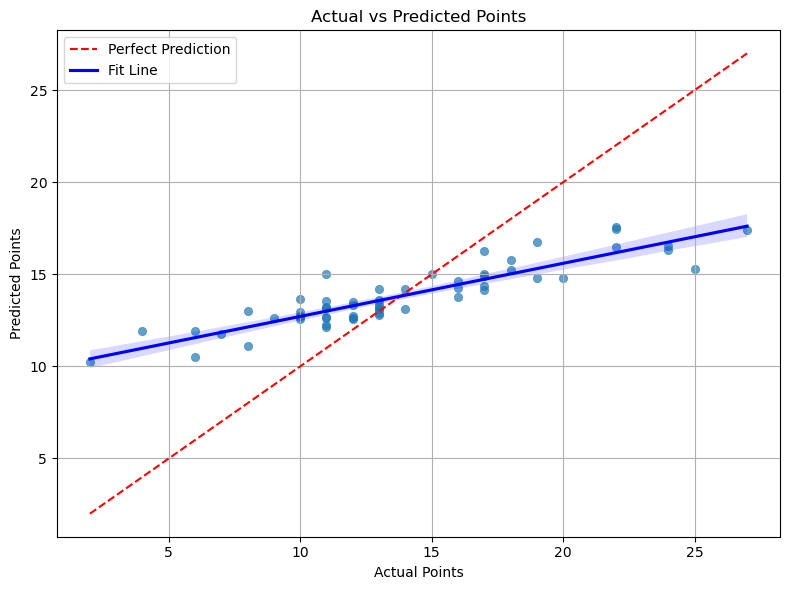

RMSE: 3.79
R² Score: 0.47


In [45]:
categorical = ['Year', 'BackToBack', 'Location', 'Month']
numerical = ['PTS_Roll5', 'PTS_Roll10', 'PTS_Roll15', 'Min_Roll3', 'Min_Roll10', 'FGA_Roll3', 'FGA_Roll10', 'PTS_Roll3', 
             'PointsPerMinute_Roll5', 'Opp_D-TOV%', 'Opp_DRtg', 'Opp_Pace', 'Opp_DRB', 'Opp_BLK', 'Opp_PF', 'Opp_TOV', 
             'Opp_D-eFG%', 'Minutes_x_FGA']

best_model, rmse, r2, plot = tune_xgb_model(df, target_column='Player_PTS',
                                      categorical_features=categorical,
                                      numeric_features=numerical)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
plot

## Predict Next Game Using Model

In [46]:
Location = 'Away'
Opponent = 'NYL'

future_df = get_future_game_data(Location, Opponent)
predict_future_game(best_model, future_df)

0    14.309144
Name: Predicted_PTS, dtype: float32

## Putting Everything Together

### Points

In [6]:
# get current prizepicks bets
prizepicks_df = get_prizepicks_bets()

# get prizepicks bets for points lines
prizepicks_points_df = prizepicks_df[prizepicks_df['attributes.stat_type'] == 'Points']

# rename columns
prizepicks_points_df = prizepicks_points_df.rename(columns={'attributes.name': 'name', 'attributes.stat_type': 'stat', 
                                                     'attributes.line_score': 'Line', 'attributes.description': 'Opponent'})

# convert to list
games_to_predict_points = prizepicks_points_df.to_dict(orient='records')

# add 'years' column
for i in games_to_predict_points:
    i['years'] = ('2025','2024', '2023', '2022', '2021', '2020')

# add 'Locations' column (home/away)
home_teams, away_teams = get_home_away_teams()

updated_games = []
for i in games_to_predict_points:
    if i['Opponent'] in home_teams:
        i['Location'] = 'Home'
        updated_games.append(i)
    elif i['Opponent'] in away_teams:
        i['Location'] = 'Away'
        updated_games.append(i)
games_to_predict_points = updated_games
        
# add 'url' column
for i in games_to_predict_points:
    url = get_link(i['name'])
    i['url'] = url

In [7]:
predictions = []

for i in games_to_predict_points:
    
    # create variables
    dates_list = []
    opp_list = []
    location_list = []
    point_list = []
    assist_list = []
    rebound_list = []
    fga_list = []
    fg_pct_list = []
    minutes_list = []
    categorical = ['Year', 'BackToBack', 'Location', 'Month']
    numerical = ['PTS_Roll5', 'PTS_Roll10', 'PTS_Roll15', 'Min_Roll3', 'Min_Roll10', 'FGA_Roll3', 'FGA_Roll10', 'PTS_Roll3', 
                 'PointsPerMinute_Roll5', 'Opp_D-TOV%', 'Opp_DRtg', 'Opp_Pace', 'Opp_DRB', 'Opp_BLK', 'Opp_PF', 'Opp_TOV', 
                 'Opp_D-eFG%', 'Minutes_x_FGA']
    
    # get data
    player_df, opp_team_df = get_data(i['url'], i['years']) # scrape data
    df = combine_data(player_df, opp_team_df) # clean and combine data
    df = engineer_features(df) # feature engineering
    
    # check if link is valid. if not, continue.
    if len(df) > 0:
        pass
    else:
        continue
    
    # train model
    best_model, rmse, r2, plot = tune_xgb_model(df, target_column='Player_PTS',
                                          categorical_features=categorical,
                                          numeric_features=numerical)
    
    # predict future game
    future_df = get_future_game_data(i['Location'], i['Opponent'])
    point_prediction = predict_future_game(best_model, future_df).iloc[0]
    
    # get sample_size, confidence, and bet
    sample_size = len(df)
    confidence = (np.sqrt(sample_size) * abs(point_prediction - i['Line'])) / rmse
    if point_prediction >= i['Line']:
        bet = 'more'
    else:
        bet = 'less'
    
    # create dictionary of prediction data
    prediction_data = {'name': i['name'],
                       'predicted_points': point_prediction,
                       'line': i['Line'],
                       'rmse': rmse,
                       'r2': r2,
                       'sample_size': sample_size,
                       'confidence': confidence,
                       'bet': bet}
    
    # append to list
    predictions.append(prediction_data)

In [8]:
predictions_df = pd.DataFrame(predictions)
predictions_df.sort_values(by='confidence', ascending=False)

KeyError: 'confidence'

### Rebounds

In [26]:
# get current prizepicks bets
prizepicks_df = get_prizepicks_bets()

# get prizepicks bets for points lines
prizepicks_rebounds_df = prizepicks_df[prizepicks_df['attributes.stat_type'] == 'Rebounds']

# rename columns
prizepicks_rebounds_df = prizepicks_rebounds_df.rename(columns={'attributes.name': 'name', 'attributes.stat_type': 'stat', 
                                                     'attributes.line_score': 'Line', 'attributes.description': 'Opponent'})

# convert to list
games_to_predict_rebounds = prizepicks_rebounds_df.to_dict(orient='records')

# add 'years' column
for i in games_to_predict_rebounds:
    i['years'] = ('2025','2024', '2023', '2022', '2021', '2020')

# add 'Locations' column (home/away)
home_teams, away_teams = get_home_away_teams()
updated_games = []
for i in games_to_predict_rebounds:
    if i['Opponent'] in home_teams:
        i['Location'] = 'Home'
        updated_games.append(i)
    elif i['Opponent'] in away_teams:
        i['Location'] = 'Away'
        updated_games.append(i)
games_to_predict_rebounds = updated_games
        
# add 'url' column
for i in games_to_predict_rebounds:
    url = get_link(i['name'])
    i['url'] = url

C:\Users\Zachary Chan\AppData\Local\Temp\ipykernel_14316\2154287371.py:833: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prizepicks_df['attributes.description'] = prizepicks_df['attributes.description'].map(mapping)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 7, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


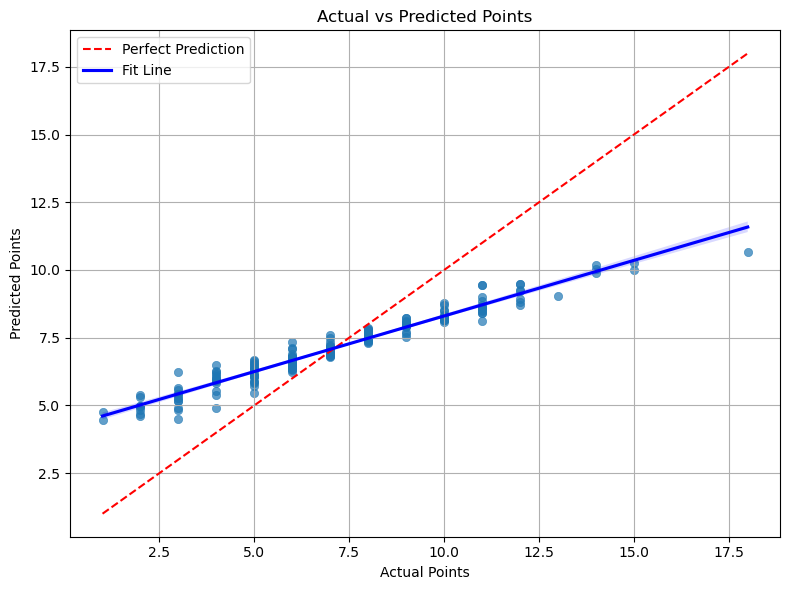

In [27]:
predictions = []

for i in games_to_predict_rebounds:
    
    # create variables
    dates_list = []
    opp_list = []
    location_list = []
    point_list = []
    assist_list = []
    rebound_list = []
    fga_list = []
    fg_pct_list = []
    minutes_list = []
    categorical = ['Year', 'BackToBack', 'Location', 'Month']
    numerical = ['REB_Roll5', 'REB_Roll10', 'REB_Roll15', 'Min_Roll3', 'Min_Roll10', 'REB_Roll3', 'FGA_Roll5',
                 'ReboundsPerMinute_Roll5', 'Opp_Pace', 'Opp_DRB', 'Opp_ORB', 'Opp_PF', 'Opp_TOV',
                 'Opp_D-eFG%', 'Opp_DRtg', 'Opp_NRtg', 'Opp_D-TOV%',
                 'Opp_3PA', 'Opp_2PA', 'Opp_FTA', 'Opp_3P%', 'Opp_2P%', 'Opp_FT%']
    
    # get data
    player_df, opp_team_df = get_data(i['url'], i['years']) # scrape data
    df = combine_data(player_df, opp_team_df) # clean and combine data
    df = engineer_features(df) # feature engineering
    
    # check if link is valid. if not, continue.
    if len(df) > 0:
        pass
    else:
        continue
    
    # train model
    best_model, rmse, r2, plot = tune_xgb_model(df, target_column='Player_REB',
                                          categorical_features=categorical,
                                          numeric_features=numerical)
    
    # predict future game
    future_df = get_future_game_data_rebounds(i['Location'], i['Opponent'])
    rebound_prediction = predict_future_game(best_model, future_df).iloc[0]
    
    # get sample_size, confidence, and bet
    sample_size = len(df)
    confidence = (np.sqrt(sample_size) * abs(rebound_prediction - i['Line'])) / rmse
    if rebound_prediction >= i['Line']:
        bet = 'more'
    else:
        bet = 'less'
    
    # create dictionary of prediction data
    prediction_data = {'name': i['name'],
                       'predicted_rebounds': rebound_prediction,
                       'line': i['Line'],
                       'rmse': rmse,
                       'r2': r2,
                       'sample_size': sample_size,
                       'confidence': confidence,
                       'bet': bet}
    
    # append to list
    predictions.append(prediction_data)

In [23]:
predictions_df = pd.DataFrame(predictions)
predictions_df.sort_values(by='confidence', ascending=False)

,name,predicted_rebounds,line,rmse,r2,sample_size,confidence,bet
3,Kamilla Cardoso,7.792301,9.5,1.487938,0.760647,66,9.323917,less
1,Courtney Williams,5.092978,4.5,2.262781,0.325630,204,3.742924,more
2,Shakira Austin,5.913629,6.5,1.569640,0.653166,100,3.735707,less
4,Jonquel Jones,8.946215,8.5,2.785935,0.345655,165,2.057382,more
0,Marina Mabrey,4.224832,4.0,1.744038,0.333417,193,1.790940,more
5,Aliyah Boston,8.435145,8.5,1.845959,0.665345,119,0.383259,less
